In [79]:
import sklearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import datetime

In [ ]:
df = pd.read_csv('../../datasets/winequality-red.csv')
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
682,8.5,0.46,0.31,2.25,0.078,32.0,58.0,0.99800,3.33,0.54,9.8,5
693,9.0,0.48,0.32,2.80,0.084,21.0,122.0,0.99840,3.32,0.62,9.4,5
1256,7.5,0.59,0.22,1.80,0.082,43.0,60.0,0.99499,3.10,0.42,9.2,5
722,7.6,0.42,0.08,2.70,0.084,15.0,48.0,0.99680,3.21,0.59,10.0,5
1182,10.2,0.40,0.40,2.50,0.068,41.0,54.0,0.99754,3.38,0.86,10.5,6


In [81]:
df.shape

(1599, 12)

In [82]:
df = df.replace('?', np.nan)

In [83]:
df = df.dropna()

In [84]:
df.shape

(1599, 12)

In [85]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [86]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [87]:
corr = df.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<AxesSubplot:>

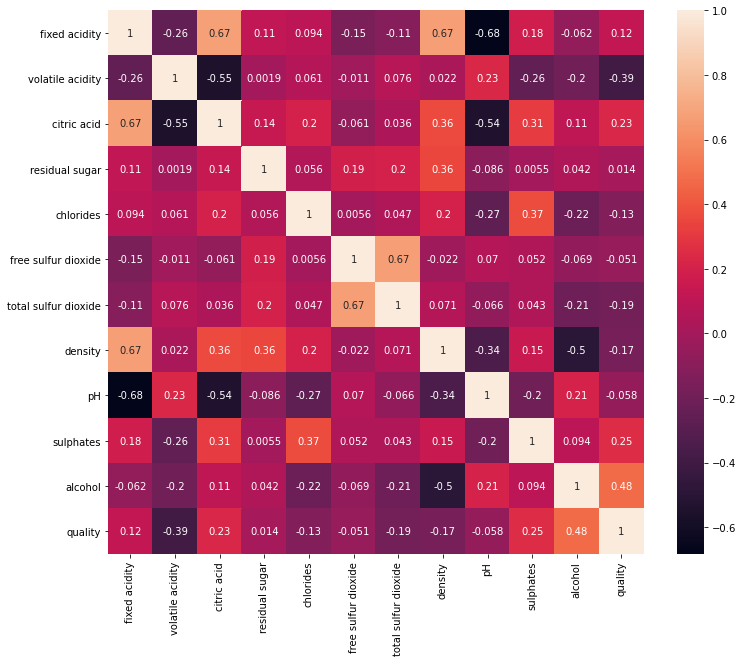

In [88]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True)

In [89]:
from sklearn.model_selection import train_test_split

X = df[['quality']]
Y = df['alcohol']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [90]:
x_train.sample()

,quality
1044,6


In [91]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression(normalize=True).fit(x_train, y_train)

In [92]:
print("Modelo Linear Simples: Intercept = {:.5}".format(linear_model.intercept_))
print("Modelo Linear Simples: Coefficient = {:.5}".format(linear_model.coef_[0]))
print("Modelo Linear Simples: Quality = {:.5} + {:.5}(Alcohol)".format(linear_model.intercept_, linear_model.coef_[0]))

Modelo Linear Simples: Intercept = 6.9913
Modelo Linear Simples: Coefficient = 0.60701
Modelo Linear Simples: Quality = 6.9913 + 0.60701(Alcohol)


In [93]:
print('Training score: ', linear_model.score(x_train, y_train))

Training score:  0.2199271732105177


In [94]:
y_pred = linear_model.predict(x_test)

In [95]:
from sklearn.metrics import r2_score
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.24800886210306783


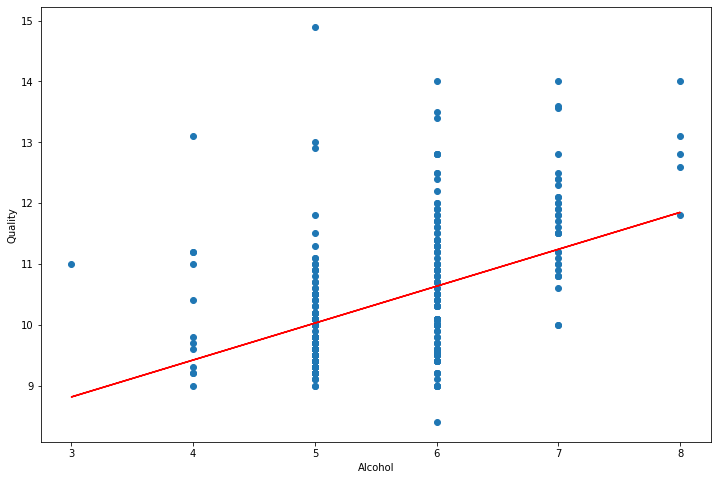

In [96]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='r')

plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

In [97]:
df = df.sample(frac=1).reset_index(drop=True)
df.shape

(1599, 12)

In [98]:
X = df[['volatile acidity','alcohol','sulphates','citric acid']]
Y = df['quality']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [99]:
linear_model = LinearRegression(normalize=True).fit(x_train, y_train)

In [100]:
print('Training score: ', linear_model.score(x_train, y_train))

Training score:  0.3465277003500009


In [101]:
predictors = x_train.columns
coef = pd.Series(linear_model.coef_, predictors).sort_values()

print(coef)

volatile acidity   -1.145969
citric acid         0.001228
alcohol             0.311319
sulphates           0.787588
dtype: float64


In [102]:
y_pred = linear_model.predict(x_test)

In [103]:
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.2897555888262512


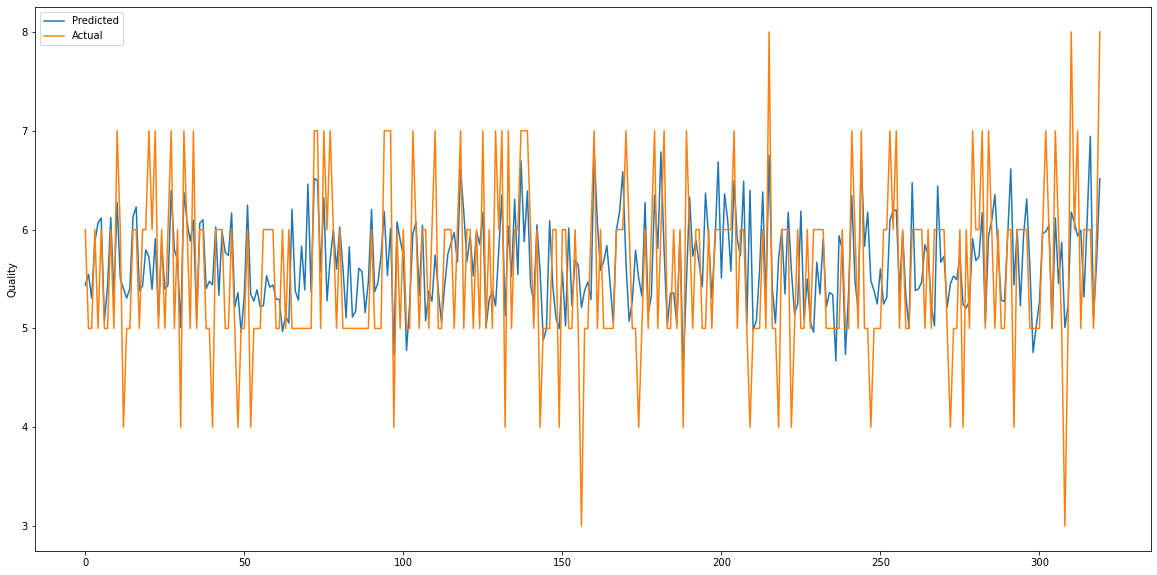

In [104]:
plt.figure(figsize = (20,10))

plt.plot(y_pred, label='Predicted')
plt.plot(y_test.values, label='Actual')

plt.ylabel('Quality')

plt.legend()
plt.show()

In [105]:
df = df.sample(frac=1).reset_index(drop=True)
df.shape

(1599, 12)

In [106]:
df = df.sort_values(['volatile acidity', 'alcohol'],ascending=[True, True])

In [107]:
from sklearn.model_selection import train_test_split

X = df[['volatile acidity','alcohol']]
Y = df['quality']

In [108]:
datapoints = np.array([X])
datapoints

array([[[ 0.12, 11.9 ],
        [ 0.12, 11.9 ],
        [ 0.12, 11.9 ],
        ...,
        [ 1.33, 10.9 ],
        [ 1.33, 10.9 ],
        [ 1.58, 10.9 ]]])

In [109]:
df[['alcohol']].min()

alcohol    8.4
dtype: float64

In [110]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_regression=PolynomialFeatures(degree=4)
X_polynomial=polynomial_regression.fit_transform(X)

In [111]:
x_train, x_test, y_train, y_test = train_test_split(X_polynomial, Y, test_size=0.2)

In [112]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression(normalize=True).fit(x_train, y_train)

In [113]:
linear_model.coef_

array([ 0.00000000e+00, -4.76394047e+02, -1.11019224e+02,  2.50773712e+02,
        1.10682410e+02,  1.27530834e+01, -4.18315544e+01, -3.98460155e+01,
       -8.54330283e+00, -6.37493836e-01, -5.51324644e-01,  4.06560360e+00,
        1.50725038e+00,  2.20934194e-01,  1.16360067e-02])

In [114]:
print('Training score: ', linear_model.score(X_polynomial,Y))

Training score:  0.3344818797257937


In [115]:
y_pred = linear_model.predict(x_test)

In [116]:
from sklearn.metrics import r2_score
print('Testing score: ', r2_score(y_test, y_pred))

Testing score:  0.1971839314526892


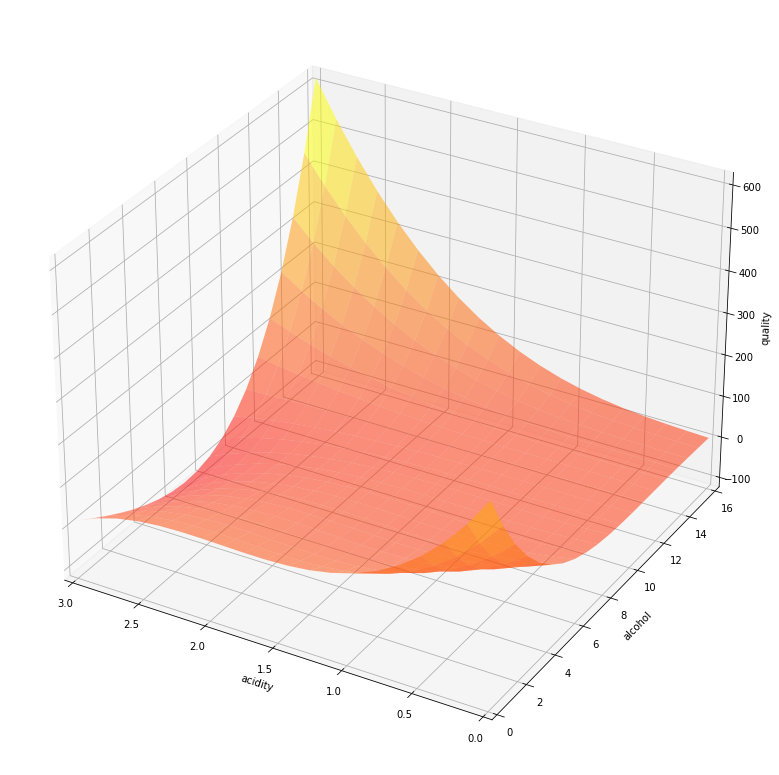

In [117]:
from matplotlib import cm

# volatile acidity 0.12 a 1.58
# alcohol 8.4 a 14.9
numero_pontos = 20

amplitude_x0 = 3
amplitude_x1 = 16

predict_x0, predict_x1 = np.meshgrid(np.linspace(0, amplitude_x0, numero_pontos), np.linspace(0, amplitude_x1, numero_pontos))

predict_x = np.concatenate((predict_x0.reshape(-1, 1), predict_x1.reshape(-1, 1)), axis=1)
X_polynomial=polynomial_regression.fit_transform(predict_x)
y_pred = linear_model.predict(X_polynomial)

fig = plt.figure(figsize=(30, 15))
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_xlim((3, 0))
ax1.set_ylim((0, 16))
ax1.set_xlabel('acidity')
ax1.set_ylabel('alcohol')
ax1.set_zlabel('quality')

surf = ax1.plot_surface(predict_x0, predict_x1, y_pred.reshape(predict_x0.shape), \
rstride=1, cstride=1, cmap=cm.autumn, alpha=0.5)
